<a href="https://colab.research.google.com/github/JeraldinneReina/Aplicando-Python/blob/main/Transacciones_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANALISIS DE CASO I - *Transacciones Bancarias***

Presentado por:
* Lina Higuera
* Daniela Romero
* Jeraldinne Reina

#1. Conexión de Colab con Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

#2. Descripción de la Ruta de archivos en Google Drive.

In [ ]:
ruta1 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/transactions_data.csv'

In [ ]:
ruta2 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/cards_data.csv'

In [ ]:
ruta3 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/users_data.csv'

In [ ]:
ruta4 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/mcc_codes.json'

In [ ]:
ruta5 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/train_fraud_labels.json'

#3. Importación de Librerias a Utilizar en el Análisis de caso.

* **Numpy :** Para Calculos Númericos  y operaciones Matemáticas (Calculos Estadíticos).
* **Pandas :** Para Manipular y analizar Datos Estructurados (filtrar, agrupar, ordenar, limpiar)
* **Sweetviz:**  Analisis exploratorio automatizado de datos (EDA) - Genera reportes visuales automáticos
* **Matplotlib:** Biblioteca de gráficos para crear visualizaciones estáticas, animadas e interactivas.


In [ ]:
## Instalación Numpy

!pip install numpy==1.26.4


In [ ]:
## Importación librería Pandas y Numpy

import pandas as pd

import numpy as np

In [ ]:
## Instalación Sweetviz

!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 69.8 MB/s eta 0:00:00


In [ ]:
## Importación librería Sweetviz

import sweetviz as sv

print("SweetViz Version : {}".format(sv.__version__))

SweetViz Version : 2.3.1


In [ ]:
## Importación librería Matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

#4. Importación de archivos CSV con pandas

##4.1.Lectura y descripción tabla Transaction_data

### Se cuenta con 11 campos:
* **Id**
* **Date:** Fecha de la transacción
* **Client_id :** id del cliente
* **Card_id :** id de la tarjeta
* **Amount :** Valor de la transacción
* **Use_chip :** Usa o no usa chip la tarjeta
* **Merchant_city:** Ciudad de compra

In [ ]:
df_t = pd.read_csv(ruta1, sep = ';')
print (df_t.head())


        id            date  client_id  card_id   amount           use_chip  \
0  7475327  1/01/2010 0:01       1556     2972  $-77.00  Swipe Transaction   
1  7475328  1/01/2010 0:02        561     4575   $14.57  Swipe Transaction   
2  7475329  1/01/2010 0:02       1129      102   $80.00  Swipe Transaction   
3  7475331  1/01/2010 0:05        430     2860  $200.00  Swipe Transaction   
4  7475332  1/01/2010 0:06        848     3915   $46.41  Swipe Transaction   

   merchant_id merchant_city merchant_state      zip   mcc errors  
0        59935        Beulah             ND  58523.0  5499    NaN  
1        67570    Bettendorf             IA  52722.0  5311    NaN  
2        27092         Vista             CA  92084.0  4829    NaN  
3        27092   Crown Point             IN  46307.0  4829    NaN  
4        13051       Harwood             MD  20776.0  5813    NaN  


In [ ]:
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1048575 non-null  int64  
 1   date            1048575 non-null  object 
 2   client_id       1048575 non-null  int64  
 3   card_id         1048575 non-null  int64  
 4   amount          1048575 non-null  object 
 5   use_chip        1048575 non-null  object 
 6   merchant_id     1048575 non-null  int64  
 7   merchant_city   1048575 non-null  object 
 8   merchant_state  934308 non-null   object 
 9   zip             928142 non-null   float64
 10  mcc             1048575 non-null  int64  
 11  errors          16437 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 96.0+ MB


In [ ]:
df_t['amount'] = df_t['amount'].astype(str).str.replace(r'[$,]', '', regex=True)
df_t['amount'] = pd.to_numeric(df_t['amount'])
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1048575 non-null  int64  
 1   date            1048575 non-null  object 
 2   client_id       1048575 non-null  int64  
 3   card_id         1048575 non-null  int64  
 4   amount          1048575 non-null  float64
 5   use_chip        1048575 non-null  object 
 6   merchant_id     1048575 non-null  int64  
 7   merchant_city   1048575 non-null  object 
 8   merchant_state  934308 non-null   object 
 9   zip             928142 non-null   float64
 10  mcc             1048575 non-null  int64  
 11  errors          16437 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 96.0+ MB


In [ ]:
df_t['date'] = pd.to_datetime(df_t['date'], dayfirst=True, format='mixed')
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   id              1048575 non-null  int64         
 1   date            1048575 non-null  datetime64[ns]
 2   client_id       1048575 non-null  int64         
 3   card_id         1048575 non-null  int64         
 4   amount          1048575 non-null  float64       
 5   use_chip        1048575 non-null  object        
 6   merchant_id     1048575 non-null  int64         
 7   merchant_city   1048575 non-null  object        
 8   merchant_state  934308 non-null   object        
 9   zip             928142 non-null   float64       
 10  mcc             1048575 non-null  int64         
 11  errors          16437 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(4)
memory usage: 96.0+ MB


In [ ]:
##identificación de columnas categoricas.

cat_cols = df_t.select_dtypes(include=['object']).columns
cat_cols

Index(['use_chip', 'merchant_city', 'merchant_state', 'errors'], dtype='object')

In [ ]:
df_t[cat_cols].describe()

,use_chip,merchant_city,merchant_state,errors
count,1048575,1048575,934308,16437
unique,2,7004,120,18
top,Swipe Transaction,ONLINE,CA,Insufficient Balance
freq,934308,114267,113971,10199


In [ ]:
## Muestra los primeros datos

df_t.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [ ]:
#Muestra los últimos datos

df_t.tail()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
1048570,8733391,2010-11-06 14:18:00,1757,4719,78.70,Swipe Transaction,97029,Muncie,IN,47304.0,5411,NaN
1048571,8733392,2010-11-06 14:19:00,218,2846,8.65,Swipe Transaction,83480,Union City,NJ,7087.0,9402,NaN
1048572,8733393,2010-11-06 14:19:00,395,2027,-56.00,Swipe Transaction,61195,Arlington,TX,76002.0,5541,NaN
1048573,8733394,2010-11-06 14:20:00,59,2087,45.00,Swipe Transaction,94612,Silver City,NM,88062.0,5655,NaN
1048574,8733395,2010-11-06 14:20:00,98,4143,47.05,Swipe Transaction,60569,Villa Grove,IL,61956.0,5300,NaN


In [ ]:
#Resumen descriptivo

df_t.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
id,1048575.0,8103260.293072,7475327.0,7788669.5,8103005.0,8417478.5,8733395.0,363062.545673
date,1048575,2010-06-06 07:57:08.911121664,2010-01-01 00:01:00,2010-03-21 10:29:00,2010-06-07 09:59:00,2010-08-22 12:55:00,2010-11-06 14:20:00,NaN
client_id,1048575.0,1031.586228,0.0,515.0,1077.0,1534.0,1998.0,582.515341
card_id,1048575.0,3373.852496,0.0,2240.0,3434.0,4722.0,6021.0,1681.176845
amount,1048575.0,43.775746,-500.0,9.03,29.55,65.28,6820.2,85.336204
merchant_id,1048575.0,47802.37097,2.0,25887.0,46284.0,67570.0,100341.0,25763.604273
zip,928142.0,51609.875193,1012.0,28645.0,48036.0,78130.0,99840.0,29404.439503
mcc,1048575.0,5563.945381,1711.0,5300.0,5499.0,5812.0,9402.0,873.025918


In [ ]:
df_t.isnull().mean()

,0
id,0.000000
date,0.000000
client_id,0.000000
card_id,0.000000
amount,0.000000
use_chip,0.000000
merchant_id,0.000000
merchant_city,0.000000
merchant_state,0.108974
zip,0.114854


In [ ]:
df_t['use_chip'].value_counts()

,count
use_chip,
Swipe Transaction,934308
Online Transaction,114267


In [ ]:
df_t['merchant_state'].value_counts(normalize=True)*100

,proportion
merchant_state,
CA,12.198440
TX,8.689961
NY,7.158025
FL,6.118860
OH,4.209533
...,...
Bangladesh,0.000214
Uzbekistan,0.000214
Tonga,0.000214


In [ ]:
df_t['use_chip'].value_counts(normalize=True)*100

,proportion
use_chip,
Swipe Transaction,89.102639
Online Transaction,10.897361


In [ ]:
df_t['merchant_city'].value_counts()

,count
merchant_city,
ONLINE,114267
Houston,11970
Miami,7782
Brooklyn,6808
Chicago,6439
...,...
Hollandale,1
Mohawk,1
Centre Hall,1


In [ ]:
segmentacion_ciudades = {
    'Plataforma': ['ONLINE'],
    'Irak': ['Bagdad'],
    'Tonga': ['Nuku Alofa'],
    'México': ['Puerto Vallarta', 'Guadalajara', 'Mexico'],
    'Canadá': ['Montreal'],
    'República Dominicana': ['Santo Domingo'],
    'Ciudad del Vaticano': ['Vatican City'],

    'Alabama (AL)': ['Arab', 'Bessemer', 'Childersburg', 'Clanton', 'Daphne', 'Dadeville', 'Elberta', 'Eight Mile', 'Heflin', 'Mobile', 'Montgomery', 'Muscle Shoals', 'New Brockton', 'Odenville', 'Opelika', 'Pell City', 'Prichard', 'Rainsville', 'Semmes', 'Tuscaloosa', 'Townley'],
    'Alaska (AK)': ['Anchorage', 'Eagle River'],
    'Arizona (AZ)': ['Avondale', 'Bullhead City', 'Camp Verde', 'Casa Grande', 'Chandler', 'Cortaro', 'Gilbert', 'Higley', 'Lake Havasu City', 'Marana', 'Mesa', 'Pahrump', 'Parker', 'Phoenix', 'Pinetop', 'Rio Rico', 'Scottsdale', 'Sedona', 'Seligman', 'Show Low', 'Sun City', 'Tempe', 'Tonopah', 'Tucson', 'Wittmann', 'Youngtown'],
    'Arkansas (AR)': ['Almyra', 'Arkoma', 'Bee Branch', 'Blytheville', 'Drasco', 'El Dorado', 'Fairfield Bay', 'Forrest City', 'Hope', 'Hot Springs Village', 'Imboden', 'Jonesboro', 'Little Rock', 'Lonoke', 'Marvell', 'Mc Gehee', 'Newhope', 'North Little Rock', 'Paragould', 'Pine Bluff', 'Piggott', 'Riverton', 'Robinson', 'Searcy', 'Sulphur', 'Texarkana', 'West Helena', 'Wickes', 'Wynne'],
    'California (CA)': ['Agoura Hills', 'Alameda', 'Alhambra', 'Altadena', 'Anaheim', 'Arcata', 'Arcadia', 'Arroyo Grande', 'Arvin', 'Atascadero', 'Atwater', 'Bakersfield', 'Baldwin Park', 'Banning', 'Bell Gardens', 'Belvedere Tiburon', 'Berkeley', 'Beverly Hills', 'Big Bear Lake', 'Blythe', 'Bonita', 'Boyes Springs', 'Boulder Creek', 'Brawley', 'Burbank', 'Burney', 'Burlingame', 'Calistoga', 'Camarillo', 'Camp Hill', 'Campbell', 'Capitola', 'Carmichael', 'Carmel', 'Carmel Valley', 'Cathedral City', 'Chino', 'Chino Hills', 'Chula Vista', 'Citrus Heights', 'Claremont', 'Clovis', 'Colton', 'Compton', 'Concord', 'Coronado', 'Costa Mesa', 'Covina', 'Crows Landing', 'Culver City', 'Daly City', 'Del Mar', 'Diamond Bar', 'Dinuba', 'Downey', 'Dublin', 'El Cajon', 'El Monte', 'El Dorado', 'Emeryville', 'Escondido', 'Fair Oaks', 'Fairfield', 'Fontana', 'Fremont', 'Fresno', 'Fullerton', 'Gardena', 'Galt', 'Glendale', 'Glendora', 'Granite Bay', 'Harbor City', 'Hayward', 'Hesperia', 'Highland', 'Hoopa', 'Huntington Park', 'Imperial Beach', 'Inglewood', 'Ione', 'Irvine', 'Irwindale', 'Joshua Tree', 'Kingsburg', 'La Crescenta', 'La Mesa', 'La Verne', 'Laguna Beach', 'Laguna Hills', 'Lodi', 'Lompoc', 'Long Beach', 'Los Altos', 'Los Angeles', 'Lynwood', 'Macdoel', 'Malibu', 'Mammoth Lakes', 'Manhattan Beach', 'Manteca', 'Marina', 'Menifee', 'Menlo Park', 'Merced', 'Milpitas', 'Mira Loma', 'Modesto', 'Monterey Park', 'Moorpark', 'Moreno Valley', 'Murphys', 'Murrieta', 'Newport Beach', 'North Hollywood', 'North Hills', 'Oakland', 'Oceanside', 'Ontario', 'Orange', 'Oxnard', 'Pacoima', 'Palo Cedro', 'Palos Verdes Peninsula', 'Pasadena', 'Patterson', 'Pinole', 'Pixley', 'Playa Del Rey', 'Pomona', 'Portola', 'Poway', 'Ramona', 'Rancho Cucamonga', 'Rancho Palos Verdes', 'Red Bluff', 'Redding', 'Redwood City', 'Rialto', 'Rio Dell', 'Riverside', 'Roseville', 'Sacramento', 'San Andreas', 'San Bernardino', 'San Carlos', 'San Clemente', 'San Diego', 'San Dimas', 'San Fernando', 'San Francisco', 'San Gabriel', 'San Jose', 'San Juan Capistrano', 'San Leandro', 'San Luis Obispo', 'San Marcos', 'San Mateo', 'San Rafael', 'Santa Ana', 'Santa Barbara', 'Santa Clarita', 'Santa Cruz', 'Sanger', 'Saratoga', 'Seal Beach', 'Seaside', 'Selma', 'Sherman Oaks', 'Shingle Springs', 'South Gate', 'South San Francisco', 'Spring Valley', 'Susanville', 'Sutter Creek', 'Sylmar', 'Thousand Oaks', 'Tracy', 'Truckee', 'Turlock', 'Ukiah', 'Vacaville', 'Vallecito', 'Vallejo', 'Valley Center', 'Valley Village', 'Van Nuys', 'Victorville', 'Vista', 'Walnut', 'Walnut Creek', 'Wasco', 'Watsonville', 'West Covina', 'West Sacramento', 'Westlake Village', 'Whittier', 'Winton', 'Woodland Hills', 'Yermo', 'Yorba Linda', 'Yreka', 'Yucaipa', 'Yuba City', 'Yountville'],
    'Carolina del Norte (NC)': ['Angier', 'Apex', 'Asheville', 'Banner Elk', 'Bakersville', 'Black Mountain', 'Blacksburg', 'Blowing Rock', 'Bunn', 'Bunnlevel', 'Burgaw', 'Cary', 'Chapel Hill', 'Charlotte', 'Connellys Springs', 'Conover', 'Cramerton', 'Creedmoor', 'Deep Gap', 'Durham', 'East Flat Rock', 'Erwin', 'Fayetteville', 'Fuquay Varina', 'Gastonia', 'Goldsboro', 'Green Lane', 'Hickory', 'High Point', 'Holly Springs', 'Horse Shoe', 'Huntersville', 'Kenansville', 'Kernersville', 'King', 'Lake Junaluska', 'Landrum', 'Laurinburg', 'Leland', 'Lincolnton', 'Maiden', 'Matthews', 'Morganton', 'Mount Ulla', 'Newton Grove', 'North Wilkesboro', 'Raleigh', 'Reidsville', 'Roan Mountain', 'Ronda', 'Sanford', 'Seaboard', 'Statesville', 'Summerfield', 'Tryon', 'Valdese', 'Wadesboro', 'Waxhaw', 'Wilmington', 'Winston Salem', 'Yadkinville', 'Zebulon'],
    'Carolina del Sur (SC)': ['Aiken', 'Anderson', 'Aynor', 'Blackville', 'Charleston', 'Cheraw', 'Chester', 'Clemson', 'Conway', 'Cross', 'Easley', 'Edgefield', 'Fort Mill', 'Greenville', 'Islandton', 'Kinards', 'Mauldin', 'Mc Bee', 'Myrtle Beach', 'North Charleston', 'North Myrtle Beach', 'Orangeburg', 'Rock Hill', 'Saluda', 'Saint Pauls', 'Sumter', 'Summerville', 'Walterboro', 'Whitmire'],
    'Colorado (CO)': ['Alamosa', 'Arvada', 'Bennett', 'Boulder', 'Castle Rock', 'Commerce City', 'Colorado Springs', 'Denver', 'Eaton', 'Evans', 'Fort Collins', 'Fruita', 'Grand Junction', 'Lone Tree', 'Longmont', 'Pueblo', 'Thornton', 'Trinidad', 'Woodland Park'],
    'Connecticut (CT)': ['Beacon Falls', 'Branford', 'Bristol', 'Cheshire', 'Coventry', 'Danbury', 'East Hartford', 'East Haven', 'Eastford', 'Greenwich', 'Hamden', 'Hartford', 'Hebron', 'Moosup', 'Naugatuck', 'Newington', 'New Milford', 'Newtown', 'North Haven', 'Old Saybrook', 'Plantsville', 'Southbury', 'Southington', 'Stafford Springs', 'Stamford', 'Stratford', 'Waterbury', 'West Hartford', 'Wethersfield'],

    'Delaware (DE)': ['Dover', 'Harrington', 'Hockessin', 'Laurel', 'Lewes', 'Milford', 'Newark', 'Rehoboth Beach', 'Selbyville', 'Smyrna', 'Wilmington'],
    'Florida (FL)': ['Altamonte Springs', 'Apopka', 'Arcadia', 'Atlantic Beach', 'Auburndale', 'Bartow', 'Belleview', 'Boca Raton', 'Bradenton', 'Brandon', 'Brooksville', 'Cape Coral', 'Clermont', 'Cocoa', 'Coral Springs', 'Davie', 'Daytona Beach', 'Deerfield Beach', 'Delray Beach', 'Doral', 'Dunedin', 'Fort Lauderdale', 'Fort Myers', 'Fort Pierce', 'Gainesville', 'Hallandale Beach', 'Hialeah', 'Hollywood', 'Homestead', 'Immokalee', 'Inverness', 'Jacksonville', 'Jensen Beach', 'Kissimmee', 'Lake Wales', 'Lakeland', 'Largo', 'Leesburg', 'Lehigh Acres', 'Live Oak', 'Miami', 'Miami Beach', 'Naples', 'New Port Richey', 'Ocala', 'Orlando', 'Osprey', 'Palm Bay', 'Palm Coast', 'Palmetto', 'Panama City', 'Pensacola', 'Pompano Beach', 'Port Charlotte', 'Port Saint Lucie', 'Punta Gorda', 'Saint Augustine', 'Saint Cloud', 'Saint Petersburg', 'Sarasota', 'Seminole', 'Spring Hill', 'Stuart', 'Tallahassee', 'Tampa', 'Titusville', 'Valparaiso', 'Venice', 'Vero Beach', 'Wellington', 'West Palm Beach', 'Chiefland', 'High Springs'],
    'Georgia (GA)': ['Acworth', 'Albany', 'Alpharetta', 'Americus', 'Athens', 'Atlanta', 'Augusta', 'Bainbridge', 'Brunswick', 'Buford', 'Cairo', 'Canton', 'Cartersville', 'Cedartown', 'Clarkesville', 'Columbus', 'Cordele', 'Covington', 'Dalton', 'Dawsonville', 'Decatur', 'Douglas', 'Dublin', 'Duluth', 'East Point', 'Ellijay', 'Fairburn', 'Fitzgerald', 'Flowery Branch', 'Forest Park', 'Fort Oglethorpe', 'Gainesville', 'Garden City', 'Greensboro', 'Griffin', 'Hiram', 'Jackson', 'Jekyll Island', 'Jesup', 'Kennesaw', 'Lawrenceville', 'Lithia Springs', 'Loganville', 'Macon', 'Marietta', 'Moultrie', 'Newnan', 'Norcross', 'Norman Park', 'Peachtree City', 'Powder Springs', 'Richmond Hill', 'Rincon', 'Rome', 'Roswell', 'Savannah', 'Smyrna', 'Snellville', 'Statesboro', 'Stone Mountain', 'Suwanee', 'Thomasville', 'Toccoa', 'Valdosta', 'Vidalia', 'Warner Robins', 'Waycross', 'Woodstock', 'Winder'],
    'Hawái (HI)': ['Haleiwa', 'Hilo', 'Kailua Kona', 'Kahului', 'Kapaa', 'Koloa', 'Mililani', 'Ocean View', 'Paia', 'Pearl City', 'Waianae', 'Wahiawa', 'Schofield Barracks'],
    'Idaho (ID)': ['Boise', 'Coeur D\'Alene', 'Cottonwood', 'Driggs', 'Eagle', 'Emmett', 'Garden City', 'Hailey', 'Idaho Falls', 'Kuna', 'Meridian', 'Moscow', 'Mullan', 'Nampa', 'Ponderay', 'Post Falls', 'Rexburg', 'Sandpoint', 'Soda Springs', 'Twin Falls', 'Wallace'],
    'Illinois (IL)': ['Alsip', 'Alton', 'Antioch', 'Arlington Heights', 'Aurora', 'Barrington', 'Bartlett', 'Batavia', 'Belleville', 'Belvidere', 'Bloomington', 'Bolingbrook', 'Bourbonnais', 'Bridgeview', 'Burr Ridge', 'Carbondale', 'Champaign', 'Chicago', 'Cicero', 'Coal Valley', 'Colona', 'Crystal Lake', 'Decatur', 'Deerfield', 'Des Plaines', 'Downers Grove', 'East Moline', 'Elgin', 'Elmhurst', 'Evanston', 'Fairmont City', 'Forsyth', 'Frankfort', 'Freeport', 'Gages Lake', 'Geneva', 'Glen Carbon', 'Glen Ellyn', 'Glendale Heights', 'Grafton', 'Gurnee', 'Harwood', 'Highland Park', 'Homer Glen', 'Jacksonville', 'Joliet', 'Kankakee', 'Lake Zurich', 'Lemont', 'Libertyville', 'Lincolnshire', 'Lisle', 'Lombard', 'Loves Park', 'Marion', 'Matteson', 'McHenry', 'Mokena', 'Moline', 'Montgomery', 'Mount Prospect', 'Mundelein', 'Naperville', 'Normal', 'Northbrook', 'Oak Brook', 'Oak Forest', 'Oak Park', 'Orland Park', 'Oswego', 'Palatine', 'Peoria', 'Peru', 'Plainfield', 'Quincy', 'Richton Park', 'Riverside', 'Rock Falls', 'Rockford', 'Rolling Meadows', 'Romeoville', 'Roselle', 'Round Lake', 'Saint Charles', 'Schaumburg', 'Skokie', 'Springfield', 'Sterling', 'Tinley Park', 'Tonica', 'Vernon Hills', 'Villa Park', 'Waukegan', 'West Chicago', 'Wheaton', 'Wilmette', 'Woodridge', 'Yorkville'],
    'Indiana (IN)': ['Anderson', 'Avon', 'Brownsburg', 'Carmel', 'Clarksville', 'Columbus', 'Corydon', 'Crawfordsville', 'Crown Point', 'Evansville', 'Fishers', 'Fort Wayne', 'Fortville', 'Greenwood', 'Hammond', 'Indianapolis', 'Jeffersonville', 'Kokomo', 'Lafayette', 'Lawrence', 'Lebanon', 'Logansport', 'Losantville', 'Madison', 'Merrillville', 'Muncie', 'New Albany', 'Noblesville', 'Plainfield', 'Portage', 'Richmond', 'Schererville', 'Sellersburg', 'South Bend', 'Terre Haute', 'Valparaiso', 'Westfield', 'Zionsville'],
    'Iowa (IA)': ['Bettendorf', 'Burlington', 'Cedar Rapids', 'Council Bluffs', 'Creston', 'Davenport', 'Des Moines', 'Dubuque', 'Eldridge', 'Fort Dodge', 'Iowa City', 'Keokuk', 'Marion', 'Marshalltown', 'Mason City', 'Muscatine', 'Oskaloosa', 'Pella', 'Waterloo'],

    'Kansas (KS)': ['Abilene', 'Andover', 'Arkansas City', 'Atchison', 'Chanute', 'Colwich', 'Dodge City', 'Emporia', 'Gardner', 'Great Bend', 'Hays', 'Hutchinson', 'Independence', 'Junction City', 'Kansas City', 'Lawrence', 'Lenexa', 'Liberal', 'Manhattan', 'McPherson', 'Merriam', 'Newton', 'Olathe', 'Ottawa', 'Overland Park', 'Pittsburg', 'Prairie Village', 'Salina', 'Shawnee', 'Topeka', 'Wichita'],
    'Kentucky (KY)': ['Ashland', 'Bardstown', 'Berea', 'Bowling Green', 'Corbin', 'Covington', 'Elizabethtown', 'Erlanger', 'Florence', 'Frankfort', 'Georgetown', 'Glasgow', 'Harrodsburg', 'Hopkinsville', 'Lexington', 'Louisville', 'Madisonville', 'Middlesboro', 'Mortons Gap', 'Mount Washington', 'Murray', 'Nicholasville', 'Owensboro', 'Paducah', 'Pikeville', 'Radcliff', 'Richmond', 'Somerset', 'Williamsburg'],
    'Luisiana (LA)': ['Alexandria', 'Baton Rouge', 'Belle Chasse', 'Bossier City', 'Covington', 'Denham Springs', 'Eros', 'Farmerville', 'Gonzales', 'Gretna', 'Harvey', 'Houma', 'Kenner', 'Labadieville', 'Lafayette', 'Lake Charles', 'Mandeville', 'Metairie', 'Mer Rouge', 'Monroe', 'New Iberia', 'New Orleans', 'Opelousas', 'Pearl River', 'Pineville', 'Ponchatoula', 'Port Allen', 'Prairieville', 'Ruston', 'Slidell', 'Sulphur', 'Thibodaux', 'Violet', 'West Monroe', 'Westwego'],
    'Maine (ME)': ['Auburn', 'Augusta', 'Biddeford', 'Boothbay', 'Brunswick', 'Caribou', 'Dexter', 'East Boothbay', 'Ellsworth', 'Falmouth', 'Fort Kent', 'Gardiner', 'Gorham', 'Gray', 'Houlton', 'Isle Of Springs', 'Kennebunk', 'Lewiston', 'Lisbon', 'Machias', 'Old Town', 'Orono', 'Portland', 'Presque Isle', 'Rockland', 'Saco', 'Sanford', 'Scarborough', 'Skowhegan', 'South Portland', 'Springvale', 'Stockton Springs', 'Topsham', 'Waterville', 'Westbrook', 'Windham', 'Yarmouth', 'York'],
    'Maryland (MD)': ['Annapolis', 'Baltimore', 'Bel Air', 'Bowie', 'California', 'Cambridge', 'Catonsville', 'Chestertown', 'Clarksville', 'Columbia', 'Crofton', 'Cumberland', 'Easton', 'Edgewood', 'Elkton', 'Ellicott City', 'Essex', 'Forest Hill', 'Frederick', 'Gaithersburg', 'Germantown', 'Glen Burnie', 'Greenbelt', 'Hagerstown', 'Hanover', 'Hyattsville', 'Laurel', 'Middle River', 'Montgomery Village', 'Odenton', 'Ocean City', 'Owings Mills', 'Parkville', 'Pasadena', 'Perry Hall', 'Pikesville', 'Randallstown', 'Rockville', 'Salisbury', 'Severna Park', 'Silver Spring', 'Takoma Park', 'Waldorf', 'Westminster', 'Wheaton', 'White Marsh'],
    'Massachusetts (MA)': ['Abington', 'Acton', 'Amherst', 'Andover', 'Arlington', 'Attleboro', 'Barnstable', 'Bedford', 'Belmont', 'Beverly', 'Boston', 'Braintree', 'Bridgewater', 'Brockton', 'Burlington', 'Cambridge', 'Canton', 'Chelmsford', 'Chelsea', 'Cohasset', 'Concord', 'Danvers', 'Dartmouth', 'Dedham', 'Dorchester', 'Dracut', 'Easton', 'Everett', 'Fairhaven', 'Fall River', 'Fitchburg', 'Framingham', 'Franklin', 'Gloucester', 'Grafton', 'Greenfield', 'Hadley', 'Hanover', 'Haverhill', 'Hingham', 'Holyoke', 'Hudson', 'Ipswich', 'Kingston', 'Lawrence', 'Lexington', 'Lowell', 'Lynn', 'Malden', 'Mansfield', 'Marblehead', 'Marlborough', 'Medford', 'Melrose', 'Methuen', 'Milford', 'New Bedford', 'Newburyport', 'Newton', 'North Adams', 'North Andover', 'North Grafton', 'Northampton', 'Norwood', 'Peabody', 'Pittsfield', 'Plymouth', 'Quincy', 'Randolph', 'Reading', 'Revere', 'Rockland', 'Salem', 'Saugus', 'Sharon', 'Shrewsbury', 'Somerville', 'Southbridge', 'Springfield', 'Stoughton', 'Taunton', 'Truro', 'Wakefield', 'Waltham', 'Watertown', 'Wellesley', 'West Roxbury', 'Westfield', 'Weymouth', 'Woburn', 'Worcester'],
    'Míchigan (MI)': ['Allen Park', 'Ann Arbor', 'Battle Creek', 'Bay City', 'Berrien Springs', 'Birmingham', 'Brighton', 'Cadillac', 'Canton', 'Chesterfield', 'Clarkston', 'Dearborn', 'Detroit', 'Dowagiac', 'East Lansing', 'Farmington', 'Flint', 'Gladwin', 'Grand Haven', 'Grand Rapids', 'Highland', 'Holland', 'Howell', 'Iron Mountain', 'Jackson', 'Kalamazoo', 'Lansing', 'Livonia', 'Manistique', 'Midland', 'Monroe', 'Mount Pleasant', 'Muskegon', 'New Baltimore', 'Novi', 'Petoskey', 'Plymouth', 'Pontiac', 'Port Huron', 'Portage', 'Rochester', 'Saginaw', 'Saint Clair Shores', 'Southfield', 'Sterling Heights', 'Traverse City', 'Troy', 'Warren', 'Waterford', 'Westland', 'Wyoming', 'Ypsilanti'],
    'Minesota (MN)': ['Apple Valley', 'Arden Hills', 'Austin', 'Bemidji', 'Belview', 'Beulah', 'Blaine', 'Bloomington', 'Brooklyn Park', 'Burnsville', 'Champlin', 'Cloquet', 'Coon Rapids', 'Duluth', 'Eagan', 'Eden Prairie', 'Edina', 'Fairmont', 'Faribault', 'Fergus Falls', 'Forest Lake', 'Fridley', 'Golden Valley', 'Grand Rapids', 'Inver Grove Heights', 'Isle', 'Lakeville', 'Lino Lakes', 'Mankato', 'Maple Grove', 'Minneapolis', 'Minnetonka', 'Monticello', 'Moorhead', 'New Brighton', 'Northfield', 'Oakdale', 'Owatonna', 'Perham', 'Pierz', 'Pillager', 'Plymouth', 'Prior Lake', 'Rochester', 'Roseville', 'Savage', 'Shakopee', 'Shoreview', 'South Saint Paul', 'Saint Cloud', 'Saint Louis Park', 'Saint Paul', 'Stillwater', 'Vadnais Heights', 'Waseca', 'White Bear Lake', 'Woodbury', 'Worthington'],
    'Misisipi (MS)': ['Biloxi', 'Brandon', 'Brookhaven', 'Byhalia', 'Canton', 'Clarksdale', 'Clinton', 'Collins', 'Columbia', 'Corinth', 'Greenwood', 'Gulfport', 'Hattiesburg', 'Jackson', 'Laurel', 'Madison', 'Meridian', 'Natchez', 'Olive Branch', 'Ocean Springs', 'Oxford', 'Pass Christian', 'Picayune', 'Ridgeland', 'Sallis', 'Starkville', 'Tupelo', 'Vicksburg', 'West Point'],
    'Misuri (MO)': ['Arnold', 'Ballwin', 'Belton', 'Blue Springs', 'Branson', 'Chesterfield', 'Columbia', 'Dardenne Prairie', 'Excelsior Springs', 'Fenton', 'Ferguson', 'Florissant', 'Grain Valley', 'Grandview', 'Hazelwood', 'Independence', 'Jefferson City', 'Joplin', 'Kansas City', 'Kirkwood', 'Lees Summit', 'Liberty', 'Manchester', 'Maryland Heights', 'Nixa', 'O Fallon', 'Oak Grove', 'Ozark', 'Poplar Bluff', 'Raytown', 'Republic', 'Richmond Heights', 'Saint Charles', 'Saint Joseph', 'Saint Louis', 'Saint Peters', 'Salesville', 'Sedalia', 'Sikeston', 'Springfield', 'Turney', 'Union Star', 'University City', 'Wildwood', 'Wentzville', 'West Plains'],
    'Montana (MT)': ['Belgrade', 'Billings', 'Bozeman', 'Butte', 'Columbia Falls', 'Dillon', 'Florence', 'Great Falls', 'Helena', 'Kalispell', 'Lolo', 'Missoula', 'Red Lodge', 'Whitefish'],
    'Nebraska (NE)': ['Bellevue', 'Columbus', 'Fremont', 'Grand Island', 'Kearney', 'Lincoln', 'Norfolk', 'Omaha', 'Papillion', 'Scottsbluff', 'Sidney'],
    'Nevada (NV)': ['Carson City', 'Fallon', 'Henderson', 'Las Vegas', 'Laughlin', 'North Las Vegas', 'Pahrump', 'Reno', 'Sparks', 'Zephyr Cove'],
    'Nuevo Hampshire (NH)': ['Bedford', 'Candia', 'Claremont', 'Concord', 'Derry', 'Dover', 'Exeter', 'Franklin', 'Hampton', 'Hudson', 'Keene', 'Laconia', 'Lebanon', 'Manchester', 'Merrimack', 'Milford', 'Nashua', 'Plaistow', 'Portsmouth', 'Rochester', 'Salem', 'Somersworth'],
    'Nueva Jersey (NJ)': ['Atlantic City', 'Bayonne', 'Belford', 'Bergenfield', 'Berkeley Heights', 'Brick', 'Bridgewater', 'Cherry Hill', 'Clifton', 'Dover', 'East Brunswick', 'Edison', 'Elmwood Park', 'Fair Lawn', 'Fort Lee', 'Franklin', 'Hackensack', 'Haledon', 'Hazlet', 'Hoboken', 'Howell', 'Jersey City', 'Lakewood', 'Linden', 'Long Branch', 'Manahawkin', 'Manasquan', 'Marlton', 'Matawan', 'Montclair', 'Morristown', 'Mount Laurel', 'New Brunswick', 'Newark', 'North Bergen', 'Nutley', 'Oradell', 'Paramus', 'Parsippany', 'Pennsauken', 'Piscataway', 'Princeton', 'Rahway', 'Ridgewood', 'Secaucus', 'Somerset', 'Toms River', 'Trenton', 'Tuckerton', 'Vineland', 'Wayne', 'West Orange', 'Woodbridge'],
    'Nueva York (NY)': ['Albany', 'Astoria', 'Auburn', 'Babylon', 'Baldwin', 'Bay Shore', 'Bayside', 'Bethpage', 'Binghamton', 'Brentwood', 'Brightwaters', 'Bronx', 'Brooklyn', 'Buffalo', 'Cambria Heights', 'Carmel', 'Central Islip', 'Centereach', 'Commack', 'Corona', 'Cortlandt Manor', 'Deer Park', 'Dewittville', 'Dix Hills', 'East Meadow', 'Elmont', 'Farmingdale', 'Flushing', 'Forest Hills', 'Fort Montgomery', 'Freeport', 'Fresh Meadows', 'Garden City', 'Geneva', 'Glen Cove', 'Great Neck', 'Hauppauge', 'Hempstead', 'Hicksville', 'Huntington Station', 'Ithaca', 'Jamaica', 'Johnson City', 'Kew Gardens', 'Lawrence', 'Levittown', 'Lindenhurst', 'Lockport', 'Long Beach', 'Long Island City', 'Lynbrook', 'Malone', 'Manhasset', 'Massapequa', 'Melville', 'Merrick', 'Middle Village', 'Middletown', 'Mineola', 'Minoa', 'Mount Vernon', 'New Rochelle', 'New York', 'Niagara Falls', 'North Tonawanda', 'Nyack', 'Ozone Park', 'Patchogue', 'Plainview', 'Port Chester', 'Port Jefferson Station', 'Poughkeepsie', 'Queens Village', 'Rego Park', 'Richmond Hill', 'Riverhead', 'Rochester', 'Rockville Centre', 'Ronkonkoma', 'Rosedale', 'Scarsdale', 'Schenectady', 'Staten Island', 'Stony Brook', 'Suffern', 'Sunnyside', 'Syracuse', 'Troy', 'Utica', 'Valley Stream', 'Wantagh', 'Watertown', 'West Hempstead', 'Westbury', 'Westhampton Beach', 'White Plains', 'Williston Park', 'Yonkers'],
    'Nuevo México (NM)': ['Alamogordo', 'Albuquerque', 'Angel Fire', 'Artesia', 'Bernalillo', 'Carlsbad', 'Clovis', 'Española', 'Farmington', 'Gallup', 'Hobbs', 'Las Vegas', 'Mentmore', 'Portales', 'Rio Rancho', 'Roswell', 'Ruidoso', 'Santa Fe', 'Silver City', 'Taos', 'Truth Or Consequences'],
    'Ohio (OH)': ['Akron', 'Alliance', 'Ashtabula', 'Avon Lake', 'Barberton', 'Beavercreek', 'Brunswick', 'Canton', 'Cincinnati', 'Cleveland', 'Columbus', 'Dayton', 'Delaware', 'Elyria', 'Fairfield', 'Findlay', 'Forest Park', 'Gahanna', 'Grove City', 'Hamilton', 'Hilliard', 'Huber Heights', 'Kent', 'Kettering', 'Lancaster', 'Lebanon', 'Lima', 'Lorain', 'Mansfield', 'Marietta', 'Marion', 'Mason', 'Massillon', 'Medina', 'Mentor', 'Mogadore', 'North Royalton', 'Parma', 'Pickerington', 'Pleasant City', 'Piqua', 'Port Clinton', 'Quaker City', 'Reynoldsburg', 'Sandusky', 'Shaker Heights', 'Springfield', 'Stow', 'Strongsville', 'Toledo', 'Twinsburg', 'Upper Arlington', 'Vandalia', 'Wadsworth', 'Warren', 'West Alexandria', 'Westerville', 'Westlake', 'Wooster', 'Xenia', 'Youngstown', 'Zanesville'],
    'Oklahoma (OK)': ['Ada', 'Ardmore', 'Bartlesville', 'Bethany', 'Broken Arrow', 'Chickasha', 'Claremore', 'Edmond', 'Enid', 'Lawton', 'McAlester', 'Miami', 'Midwest City', 'Moore', 'Muskogee', 'Norman', 'Oklahoma City', 'Owasso', 'Ponca City', 'Sand Springs', 'Shawnee', 'Stillwater', 'Tahlequah', 'Thackerville', 'Tulsa'],
    'Oregón (OR)': ['Albany', 'Ashland', 'Beaverton', 'Bend', 'Canby', 'Central Point', 'Corvallis', 'Eugene', 'Grants Pass', 'Gresham', 'Hillsboro', 'Keizer', 'Lake Oswego', 'McMinnville', 'Medford', 'Milwaukie', 'Newberg', 'Oregon City', 'Pendleton', 'Portland', 'Redmond', 'Roseburg', 'Salem', 'Sherwood', 'Springfield', 'The Dalles', 'Tigard', 'Troutdale', 'Tualatin', 'West Linn', 'Wilsonville', 'Woodburn'],
    'Pensilvania (PA)': ['Allentown', 'Altoona', 'Ardmore', 'Bethel Park', 'Bethlehem', 'Bensalem', 'Camp Hill', 'Canonsburg', 'Carlisle', 'Chambersburg', 'Chester', 'Cranberry Township', 'Downingtown', 'Doylestown', 'Du Bois', 'Easton', 'Erie', 'Greensburg', 'Harrisburg', 'Hazleton', 'Horsham', 'Hummelstown', 'Johnstown', 'King Of Prussia', 'Lafayette', 'Lancaster', 'Lebanon', 'Levittown', 'Lower Burrell', 'McKeesport', 'Mechanicsburg', 'Monroeville', 'Mount Lebanon', 'Murrysville', 'Nazareth', 'New Brighton', 'New Castle', 'Norristown', 'Philadelphia', 'Phoenixville', 'Pittsburgh', 'Pittston', 'Pottstown', 'Reading', 'Richlandtown', 'Scranton', 'Souderton', 'State College', 'Stroudsburg', 'Sutersville', 'Upper Darby', 'Warminster', 'Washington', 'Watsontown', 'West Chester', 'Wilkes Barre', 'Williamsport', 'Willow Grove', 'York'],
    'Rhode Island (RI)': ['Barrington', 'Bristol', 'Coventry', 'Cranston', 'East Greenwich', 'East Providence', 'Johnston', 'Newport', 'North Kingstown', 'Pawtucket', 'Portsmouth', 'Providence', 'Warwick', 'Westerly', 'Woonsocket'],

    'Tennessee (TN)': ['Alcoa', 'Antioch', 'Athens', 'Bartlett', 'Brentwood', 'Bristol', 'Chattanooga', 'Clarksville', 'Cleveland', 'Collierville', 'Columbia', 'Cookeville', 'Cordova', 'Dickson', 'Dyersburg', 'Farragut', 'Franklin', 'Gallatin', 'Germantown', 'Greeneville', 'Hendersonville', 'Hermitage', 'Jackson', 'Johnson City', 'Kingsport', 'Knoxville', 'Lebanon', 'Lenoir City', 'Maryville', 'Memphis', 'Morristown', 'Mount Juliet', 'Murfreesboro', 'Nashville', 'Oak Ridge', 'Old Hickory', 'Pigeon Forge', 'Sevierville', 'Smyrna', 'Spring Hill', 'Sunbright', 'White House', 'Whites Creek'],
    'Texas (TX)': ['Abilene', 'Aledo', 'Alice', 'Alvin', 'Alvord', 'Amarillo', 'Arlington', 'Athens', 'Austin', 'Baytown', 'Beaumont', 'Bedford', 'Beeville', 'Belton', 'Brownsville', 'Bryan', 'Buda', 'Burleson', 'Carrollton', 'Cedar Hill', 'Cedar Park', 'College Station', 'Colleyville', 'Conroe', 'Coppell', 'Corpus Christi', 'Dallas', 'Deer Park', 'Denison', 'Denton', 'DeSoto', 'Dickinson', 'Duncanville', 'Edcouch', 'El Paso', 'Euless', 'Farmers Branch', 'Flower Mound', 'Forney', 'Fort Worth', 'Friendswood', 'Frisco', 'Garland', 'Georgetown', 'Grand Prairie', 'Grapevine', 'Haltom City', 'Harlingen', 'Houston', 'Humble', 'Irving', 'Katy', 'Keller', 'Killeen', 'La Porte', 'League City', 'Lewisville', 'Longview', 'Lubbock', 'Lufkin', 'Mansfield', 'Marble Falls', 'Marshall', 'McAllen', 'McKinney', 'Mesquite', 'Midland', 'Missouri City', 'Nacogdoches', 'New Braunfels', 'North Richland Hills', 'Odessa', 'Pasadena', 'Pearland', 'Pflugerville', 'Plano', 'Port Arthur', 'Richardson', 'Richmond', 'Round Rock', 'Rowlett', 'San Angelo', 'San Antonio', 'San Benito', 'San Marcos', 'Seguin', 'Sherman', 'Southlake', 'Stafford', 'Sugar Land', 'Temple', 'Texarkana', 'Texas City', 'Thackerville', 'The Woodlands', 'Tyler', 'Victoria', 'Waco', 'Weatherford', 'Weslaco', 'Wichita Falls', 'Wylie'],
    'Utah (UT)': ['American Fork', 'Bountiful', 'Cedar City', 'Clearfield', 'Cottonwood Heights', 'Draper', 'Herriman', 'Layton', 'Lehi', 'Logan', 'Murray', 'North Salt Lake', 'Ogden', 'Orem', 'Park City', 'Payson', 'Pleasant Grove', 'Provo', 'Riverton', 'Saint George', 'Salt Lake City', 'Sandy', 'Saratoga Springs', 'South Jordan', 'Spanish Fork', 'Springville', 'Taylorsville', 'Tooele', 'West Jordan', 'West Valley City'],
    'Vermont (VT)': ['Bennington', 'Brattleboro', 'Burlington', 'Essex', 'Middlebury', 'Montpelier', 'Newport', 'Rutland', 'South Burlington', 'White River Junction', 'Williston'],
    'Virginia (VA)': ['Alexandria', 'Annandale', 'Arlington', 'Arrington', 'Ashland', 'Barboursville', 'Bedford', 'Blacksburg', 'Bristol', 'Charlottesville', 'Chesapeake', 'Chester', 'Colonial Heights', 'Danville', 'Fairfax', 'Falls Church', 'Forest', 'Fredericksburg', 'Glen Allen', 'Hampton', 'Harrisonburg', 'Herndon', 'Leesburg', 'Lexington', 'Lynchburg', 'Manassas', 'Martinsville', 'Mechanicsville', 'Newport News', 'Norfolk', 'Petersburg', 'Portsmouth', 'Radford', 'Reston', 'Richmond', 'Riner', 'Roanoke', 'Shawsville', 'Smithfield', 'Somerset', 'South Boston', 'Springfield', 'Staunton', 'Sterling', 'Suffolk', 'Tysons Corner', 'Vienna', 'Virginia Beach', 'Warrenton', 'Williamsburg', 'Winchester', 'Woodbridge'],
    'Virginia Occidental (WV)': ['Barboursville', 'Beckley', 'Bluefield', 'Charleston', 'Clarksburg', 'Dunbar', 'Fairmont', 'Frametown', 'Huntington', 'Kenna', 'Lewisburg', 'Logan', 'Mannington', 'Martinsburg', 'Morgantown', 'Moundsville', 'Parkersburg', 'Princeton', 'Ranson', 'Rivesville', 'Scott Depot', 'Weirton', 'Weston', 'Wheeling'],
    'Washington (WA)': ['Aberdeen', 'Auburn', 'Bellevue', 'Bellingham', 'Bothell', 'Bremerton', 'Centralia', 'Covington', 'Edmonds', 'Ellensburg', 'Everett', 'Federal Way', 'Grayland', 'Issaquah', 'Kennewick', 'Kent', 'Kirkland', 'Lacey', 'Longview', 'Lynnwood', 'Marysville', 'Mercer Island', 'Moses Lake', 'Mount Vernon', 'Olympia', 'Pasco', 'Port Angeles', 'Pullman', 'Redmond', 'Renton', 'Richland', 'Sammamish', 'Seattle', 'Shoreline', 'Silverdale', 'Spokane', 'Tacoma', 'Vancouver', 'Walla Walla', 'Wenatchee', 'Yakima'],
    'Wisconsin (WI)': ['Appleton', 'Beloit', 'Brookfield', 'Burlington', 'Caledonia', 'Chippewa Falls', 'Cudahy', 'De Pere', 'Eau Claire', 'Fitchburg', 'Fond Du Lac', 'Franklin', 'Green Bay', 'Greenfield', 'Janesville', 'Kaukauna', 'Kenosha', 'La Crosse', 'Madison', 'Manitowoc', 'Markesan', 'Marshfield', 'Menasha', 'Menomonee Falls', 'Mequon', 'Milwaukee', 'Muskego', 'Neenah', 'New Berlin', 'Oak Creek', 'Oshkosh', 'Peshtigo', 'Pleasant Prairie', 'Racine', 'Sheboygan', 'South Milwaukee', 'Stevens Point', 'Sun Prairie', 'Superior', 'Waukesha', 'Wausau', 'Wauwatosa', 'West Allis', 'Whitewater', 'Wisconsin Rapids'],
    'Wyoming (WY)': ['Cheyenne', 'Cody', 'Evanston', 'Gillette', 'Jackson', 'Laramie', 'Powell', 'Rawlins', 'Riverton', 'Rock Springs', 'Sheridan', 'Thermopolis']
}

##4.2. Lectura y descripción tabla Cards_data

Summary statistics

In [ ]:
df_c = pd.read_csv(ruta2, sep = ';')
print (df_c.head())


     id  client_id  card_brand        card_type  card_number expires  cvv  \
0  4524        825        Visa            Debit  4,34468E+15  dic-22  623   
1  2731        825        Visa            Debit  4,95697E+15  dic-20  393   
2  3701        825        Visa            Debit  4,58231E+15  feb-24  719   
3    42        825        Visa           Credit  4,87949E+15  ago-24  693   
4  4659        825  Mastercard  Debit (Prepaid)  5,72287E+15  mar-09   75   

  has_chip  num_cards_issued credit_limit acct_open_date  \
0      YES                 2     $ 24.295         sep-02   
1      YES                 2     $ 21.968         abr-14   
2      YES                 2     $ 46.414         jul-03   
3       NO                 1     $ 12.400         ene-03   
4      YES                 1         $ 28         sep-08   

   year_pin_last_changed card_on_dark_web  
0                   2008               No  
1                   2014               No  
2                   2004               No  


In [ ]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   object
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(5), object(8)
memory usage: 624.3+ KB


In [ ]:
## me indica las colunmas categoricas
cat_cols = df_c.select_dtypes(include=['object']).columns
cat_cols

Index(['card_brand', 'card_type', 'card_number', 'expires', 'has_chip',
       'credit_limit', 'acct_open_date', 'card_on_dark_web'],
      dtype='object')

In [ ]:
df_c[cat_cols].describe()

,card_brand,card_type,card_number,expires,has_chip,credit_limit,acct_open_date,card_on_dark_web
count,6146,6146,6146,6146,6146,6146,6146,6146
unique,4,3,6085,259,2,3654,303,1
top,Mastercard,Debit,"4,49557E+15",feb-20,YES,$ 0,feb-20,No
freq,3209,3511,3,377,5500,31,607,6146


In [ ]:
df_c.head() #Muestra los primeros datos

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,"4,34468E+15",dic-22,623,YES,2,$ 24.295,sep-02,2008,No
1,2731,825,Visa,Debit,"4,95697E+15",dic-20,393,YES,2,$ 21.968,abr-14,2014,No
2,3701,825,Visa,Debit,"4,58231E+15",feb-24,719,YES,2,$ 46.414,jul-03,2004,No
3,42,825,Visa,Credit,"4,87949E+15",ago-24,693,NO,1,$ 12.400,ene-03,2012,No
4,4659,825,Mastercard,Debit (Prepaid),"5,72287E+15",mar-09,75,YES,1,$ 28,sep-08,2009,No


In [ ]:
df_c.tail() #Muestra los últimos datos

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
6141,5361,185,Amex,Credit,"3,0061E+14",ene-24,663,YES,1,$ 6.900,nov-00,2013,No
6142,2711,185,Visa,Credit,"4,71852E+15",ene-21,492,YES,2,$ 5.700,abr-12,2012,No
6143,1305,1007,Mastercard,Credit,"5,92951E+15",ago-20,237,NO,2,$ 9.200,feb-12,2012,No
6144,743,1110,Mastercard,Debit,"5,58977E+15",ene-20,630,YES,1,$ 28.074,ene-20,2020,No
6145,3199,1110,Visa,Credit,"4,99401E+15",dic-20,120,YES,1,$ 14.400,may-17,2017,No


In [ ]:
df_c.describe().transpose() #Resumen descriptivo

,count,mean,std,min,25%,50%,75%,max
id,6146.0,3072.500000,1774.341709,0.0,1536.25,3072.5,4608.75,6145.0
client_id,6146.0,994.939636,578.614626,0.0,492.25,992.0,1495.00,1999.0
cvv,6146.0,506.220794,289.431123,0.0,257.00,516.5,756.00,999.0
num_cards_issued,6146.0,1.503091,0.519191,1.0,1.00,1.0,2.00,3.0
year_pin_last_changed,6146.0,2013.436707,4.270699,2002.0,2010.00,2013.0,2017.00,2020.0


In [ ]:
df_c.isnull().sum()

,0
id,0
client_id,0
card_brand,0
card_type,0
card_number,0
expires,0
cvv,0
has_chip,0
num_cards_issued,0
credit_limit,0


In [ ]:
df_c['card_type'].value_counts()

,count
card_type,
Debit,3511
Credit,2057
Debit (Prepaid),578


In [ ]:
df_c['card_type'].value_counts(normalize=True)*100

,proportion
card_type,
Debit,57.126586
Credit,33.468923
Debit (Prepaid),9.404491


In [ ]:
df_c['has_chip'].value_counts()

,count
has_chip,
YES,5500
NO,646


In [ ]:
df_c['has_chip'].value_counts(normalize=True)*100

,proportion
has_chip,
YES,89.489099
NO,10.510901


In [ ]:
df_c['card_on_dark_web'].value_counts()

,count
card_on_dark_web,
No,6146


In [ ]:
df_c['card_on_dark_web'].value_counts(normalize=True)*100

,proportion
card_on_dark_web,
No,100.0


In [ ]:
#Unión de la table transacciones y tarjetas
df_merged_tc = pd.merge(df_t, df_c, left_on='card_id', right_on='id', how='left')
display(df_merged_tc.head())
display(df_merged_tc.info())

,id_x,date,client_id_x,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,Debit (Prepaid),"5,49759E+15",jul-22,306,YES,2,$ 55,may-08,2008,No
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,Credit,"5,17584E+15",dic-24,438,YES,1,$ 9.100,sep-05,2015,No
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,Debit,"5,87499E+15",may-20,256,YES,1,$ 14.802,ene-06,2008,No
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,...,Debit,"5,34683E+15",oct-24,54,NO,2,$ 37.634,may-04,2006,No
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,Debit,"4,35419E+15",ene-20,120,YES,1,$ 19.113,jul-09,2014,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 25 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   id_x                   1048575 non-null  int64         
 1   date                   1048575 non-null  datetime64[ns]
 2   client_id_x            1048575 non-null  int64         
 3   card_id                1048575 non-null  int64         
 4   amount                 1048575 non-null  float64       
 5   use_chip               1048575 non-null  object        
 6   merchant_id            1048575 non-null  int64         
 7   merchant_city          1048575 non-null  object        
 8   merchant_state         934308 non-null   object        
 9   zip                    928142 non-null   float64       
 10  mcc                    1048575 non-null  int64         
 11  errors                 16437 non-null    object        
 12  id_y                   10485

None

##4.3. Lectura y descripción tabla users_data

Summary statistics

In [ ]:
df_u = pd.read_csv(ruta3, sep = ';')
print (df_u.head())


     id  current_age  retirement_age  birth_year  birth_month  gender  \
0   825           53              66        1966           11  Female   
1  1746           53              68        1966           12  Female   
2  1718           81              67        1938           11  Female   
3   708           63              63        1957            1  Female   
4  1164           43              70        1976            9    Male   

                    address  latitude  longitude per_capita_income  \
0             462 Rose Lane     34.15    -117.76          $ 29.278   
1    3606 Federal Boulevard     40.76     -73.74          $ 37.891   
2           766 Third Drive     34.02    -117.89          $ 22.681   
3          3 Madison Street     40.71     -73.99         $ 163.145   
4  9620 Valley Stream Drive     37.76    -122.44          $ 53.797   

  yearly_income total_debt  credit_score  num_credit_cards  
0      $ 59.696  $ 127.613           787                 5  
1      $ 77.254  $

In [ ]:
df_u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB


In [ ]:
df_u['per_capita_income'] = df_u['per_capita_income'].astype(str).str.replace(r'[$,]', '', regex=True)
df_u['per_capita_income'] = pd.to_numeric(df_u['per_capita_income'])
df_u['yearly_income'] = df_u['yearly_income'].astype(str).str.replace(r'[$,]', '', regex=True)
df_u['yearly_income'] = pd.to_numeric(df_u['yearly_income'])
df_u['total_debt'] = df_u['total_debt'].astype(str).str.replace(r'[$,]', '', regex=True)
df_u['total_debt'] = pd.to_numeric(df_u['total_debt'])
df_u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   float64
 10  yearly_income      2000 non-null   float64
 11  total_debt         2000 non-null   float64
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 218.9+ KB


In [ ]:
## me indica las colunmas categoricas
cat_cols = df_u.select_dtypes(include=['object']).columns
cat_cols

Index(['gender', 'address', 'total_debt'], dtype='object')

In [ ]:
df_u[cat_cols].describe()

,gender,address,total_debt
count,2000,2000,2000
unique,2,1999,1880
top,Female,506 Washington Lane,$ 0
freq,1016,2,102


In [ ]:
df_u.head() #Muestra los primeros datos

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29.278,59.696,$ 127.613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37.891,77.254,$ 191.349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22.681,33.483,$ 196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163.145,249.925,$ 202.328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53.797,109.687,$ 183.855,675,1


In [ ]:
df_u.tail() #Muestra los últimos datos

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
1995,986,32,70,1987,7,Male,6577 Lexington Lane,40.65,-73.58,23.550,48.010,$ 87.837,703,3
1996,1944,62,65,1957,11,Female,2 Elm Drive,38.95,-84.54,24.218,49.378,$ 104.480,740,4
1997,185,47,67,1973,1,Female,276 Fifth Boulevard,40.66,-74.19,15.175,30.942,$ 71.066,779,3
1998,1007,66,60,1954,2,Male,259 Valley Boulevard,40.24,-76.92,25.336,54.654,$ 27.241,618,1
1999,1110,21,60,1998,11,Female,472 Ocean View Street,42.86,-71.48,32.325,65.909,$ 181.261,673,2


In [ ]:
df_u.describe().transpose() #Resumen descriptivo

,count,mean,std,min,25%,50%,75%,max
id,2000.0,999.500000,577.494589,0.00,499.7500,999.5000,1499.250,1999.000
current_age,2000.0,45.391500,18.414092,18.00,30.0000,44.0000,58.000,101.000
retirement_age,2000.0,66.237500,3.628867,50.00,65.0000,66.0000,68.000,79.000
birth_year,2000.0,1973.803000,18.421234,1918.00,1961.0000,1975.0000,1989.000,2002.000
birth_month,2000.0,6.439000,3.565338,1.00,3.0000,7.0000,10.000,12.000
latitude,2000.0,37.389225,5.114324,20.88,33.8375,38.2500,41.200,61.200
longitude,2000.0,-91.554765,16.283293,-159.41,-97.3950,-86.4400,-80.130,-68.670
per_capita_income,2000.0,23.141928,11.324137,0.00,16.8245,20.5810,26.286,163.145
yearly_income,2000.0,46.978118,35.717836,1.00,32.8470,40.8575,52.859,920.000
credit_score,2000.0,709.734500,67.221949,480.00,681.0000,711.5000,753.000,850.000


In [ ]:
df_u.isnull().sum()

,0
id,0
current_age,0
retirement_age,0
birth_year,0
birth_month,0
gender,0
address,0
latitude,0
longitude,0
per_capita_income,0


In [ ]:
df_u['gender'].value_counts()

,count
gender,
Female,1016
Male,984


In [ ]:
df_u['gender'].value_counts(normalize=True)*100

,proportion
gender,
Female,50.8
Male,49.2


## 4.4 Data json

In [ ]:
import json

ruta4 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/mcc_codes.json'

with open(ruta4, 'r') as f:
    for i, line in enumerate(f):
        print(f"Line {i+1}: {line.strip()}")
        if i > 5: # Print only the first few lines to inspect
            break

Line 1: {
Line 2: "5812": "Eating Places and Restaurants",
Line 3: "5541": "Service Stations",
Line 4: "7996": "Amusement Parks, Carnivals, Circuses",
Line 5: "5411": "Grocery Stores, Supermarkets",
Line 6: "4784": "Tolls and Bridge Fees",
Line 7: "4900": "Utilities - Electric, Gas, Water, Sanitary",


In [ ]:
import json

ruta5 = '/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/train_fraud_labels.json'

with open(ruta5, 'r') as f:
    for i, line in enumerate(f):
        print(f"Line {i+1}: {line.strip()}")
        if i > 5: # Print only the first few lines to inspect
            break

Buffered data was truncated after reaching the output size limit.

In [ ]:
df3 = pd.read_json('/content/drive/MyDrive/Bases_de_Datos/Analisis_de_casos_transacciones/mcc_codes.json', orient='index')
df3.reset_index(inplace=True)
df3.columns = ['MCC_Code', 'Description']
df3.head()

,MCC_Code,Description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


# 5. Visualizaciones

## 5.1. Análisis Univariado

<Axes: xlabel='use_chip', ylabel='count'>

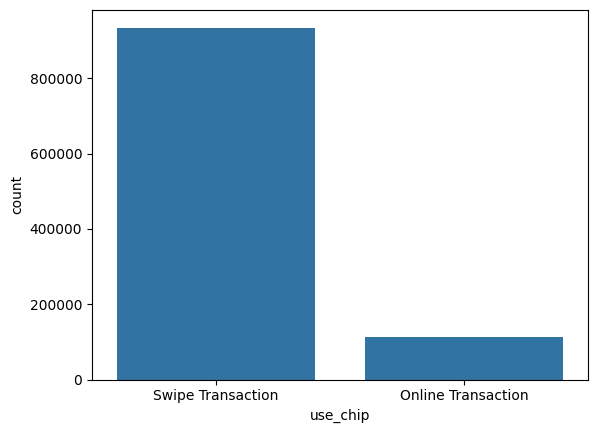

In [ ]:
##Transacciones - Uso Chip
sns.countplot(data=df_t, x='use_chip')

/tmp/ipython-input-1352964377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_cities_percentage.index, y=top_cities_percentage.values, palette="viridis")


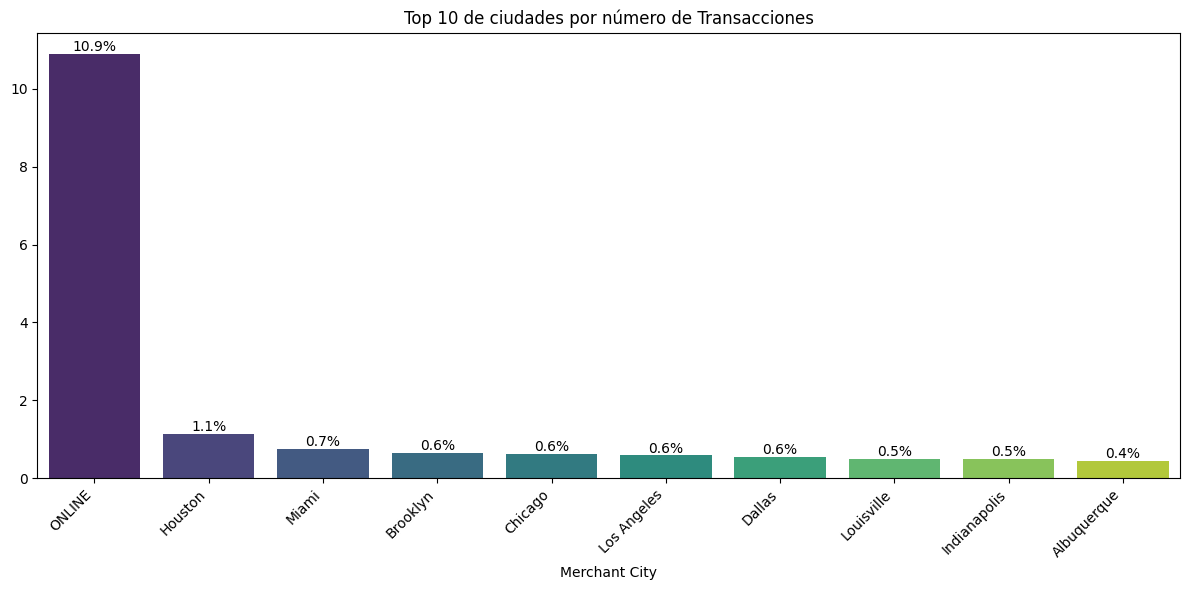

In [ ]:
top_cities = df_t['merchant_city'].value_counts().nlargest(10)
top_cities_percentage = (top_cities / len(df_t)) * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_cities_percentage.index, y=top_cities_percentage.values, palette="viridis")
plt.xlabel("Merchant City")
plt.title("Top 10 de ciudades por número de Transacciones")
plt.xticks(rotation=45, ha='right')

# Add percentages on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1529104699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_states_percentage.index, y=top_states_percentage.values, palette="viridis")


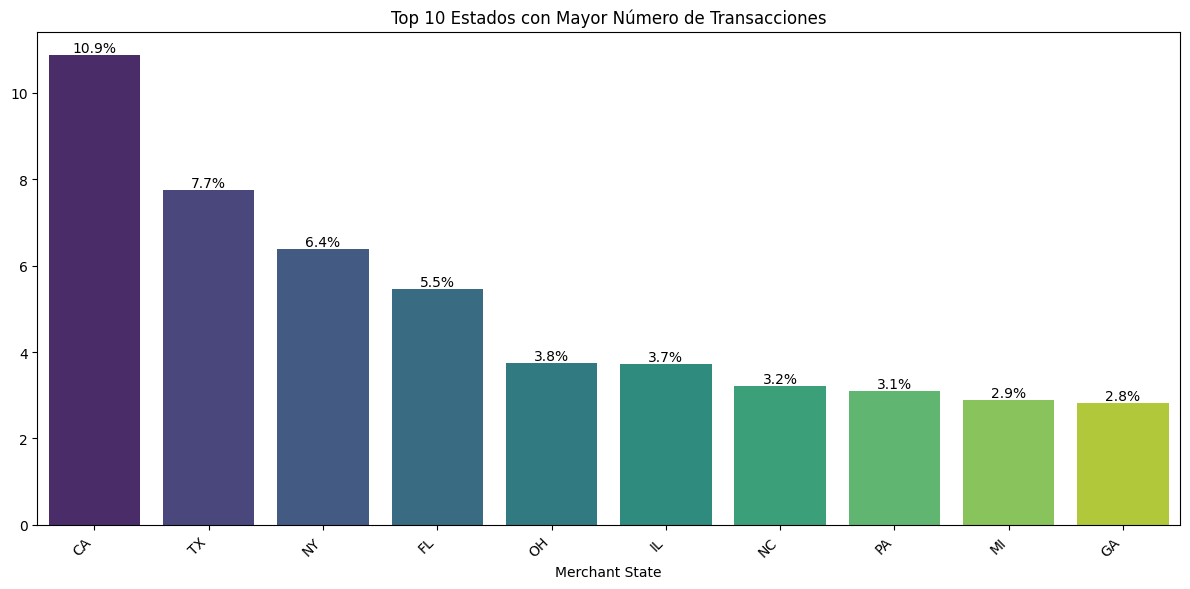

In [ ]:
top_states = df_t['merchant_state'].value_counts().nlargest(10)
top_states_percentage = (top_states / len(df_t)) * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_states_percentage.index, y=top_states_percentage.values, palette="viridis")
plt.xlabel("Merchant State")
plt.title("Top 10 Estados con Mayor Número de Transacciones")
plt.xticks(rotation=45, ha='right')

# Add percentages on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

<Axes: ylabel='count'>

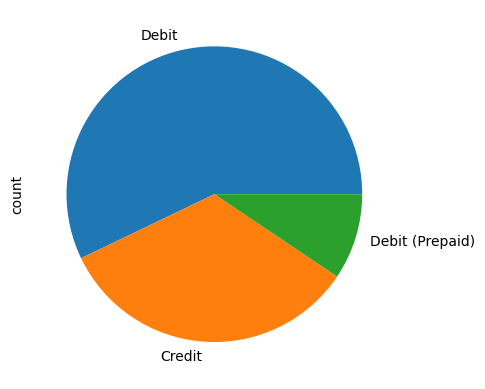

In [ ]:
## Cards
df_c.card_type.value_counts().plot(kind='pie')

<Axes: ylabel='count'>

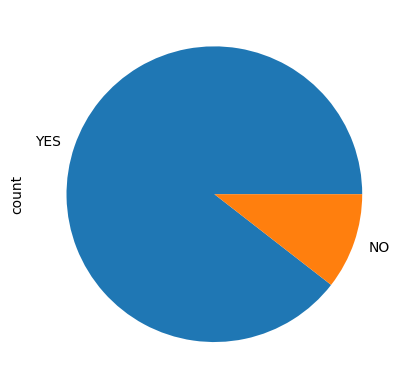

In [ ]:
##Cards
df_c.has_chip.value_counts().plot(kind='pie')

<Axes: xlabel='gender', ylabel='count'>

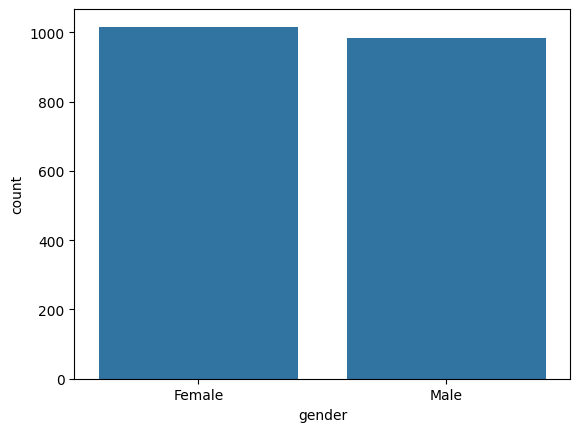

In [ ]:
#User
sns.countplot(data=df_u, x='gender')

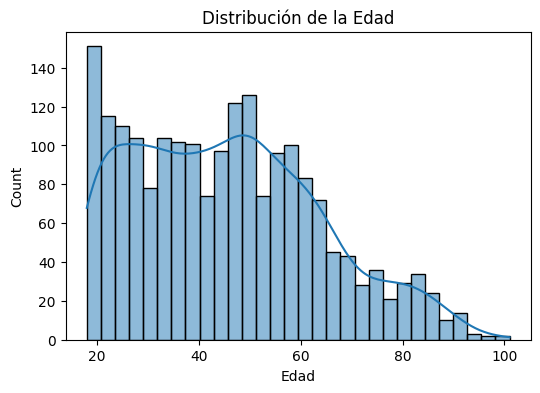

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_u['current_age'], bins=30, kde=True)
plt.xlabel("Edad")
plt.title("Distribución de la Edad")
plt.show()

<Axes: xlabel='current_age', ylabel='per_capita_income'>

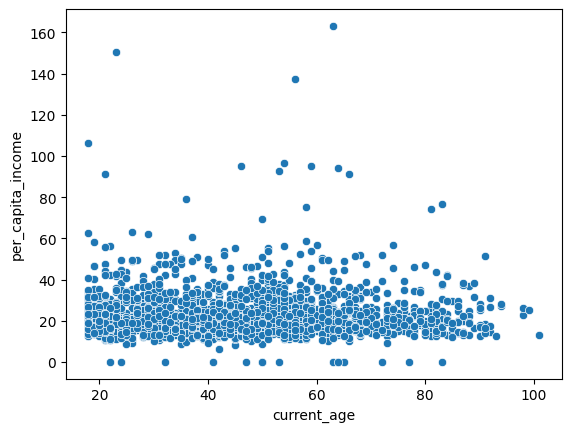

In [ ]:
##per_capita- current_age
sns.scatterplot(data=df_u, x='current_age', y='per_capita_income')

<Axes: xlabel='credit_score', ylabel='per_capita_income'>

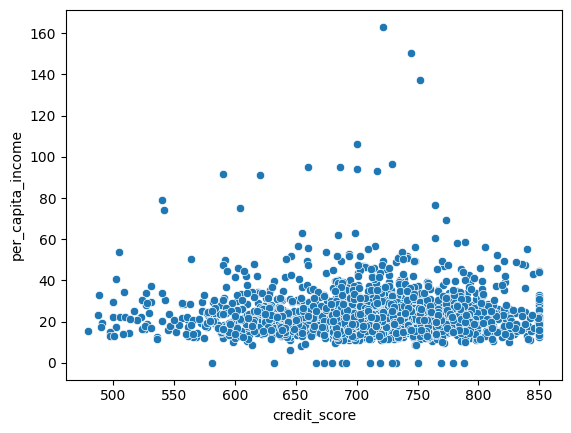

In [ ]:
##per capita - credit score
sns.scatterplot(data=df_u, x='credit_score', y='per_capita_income')

##5.2. Análisis Bivariado

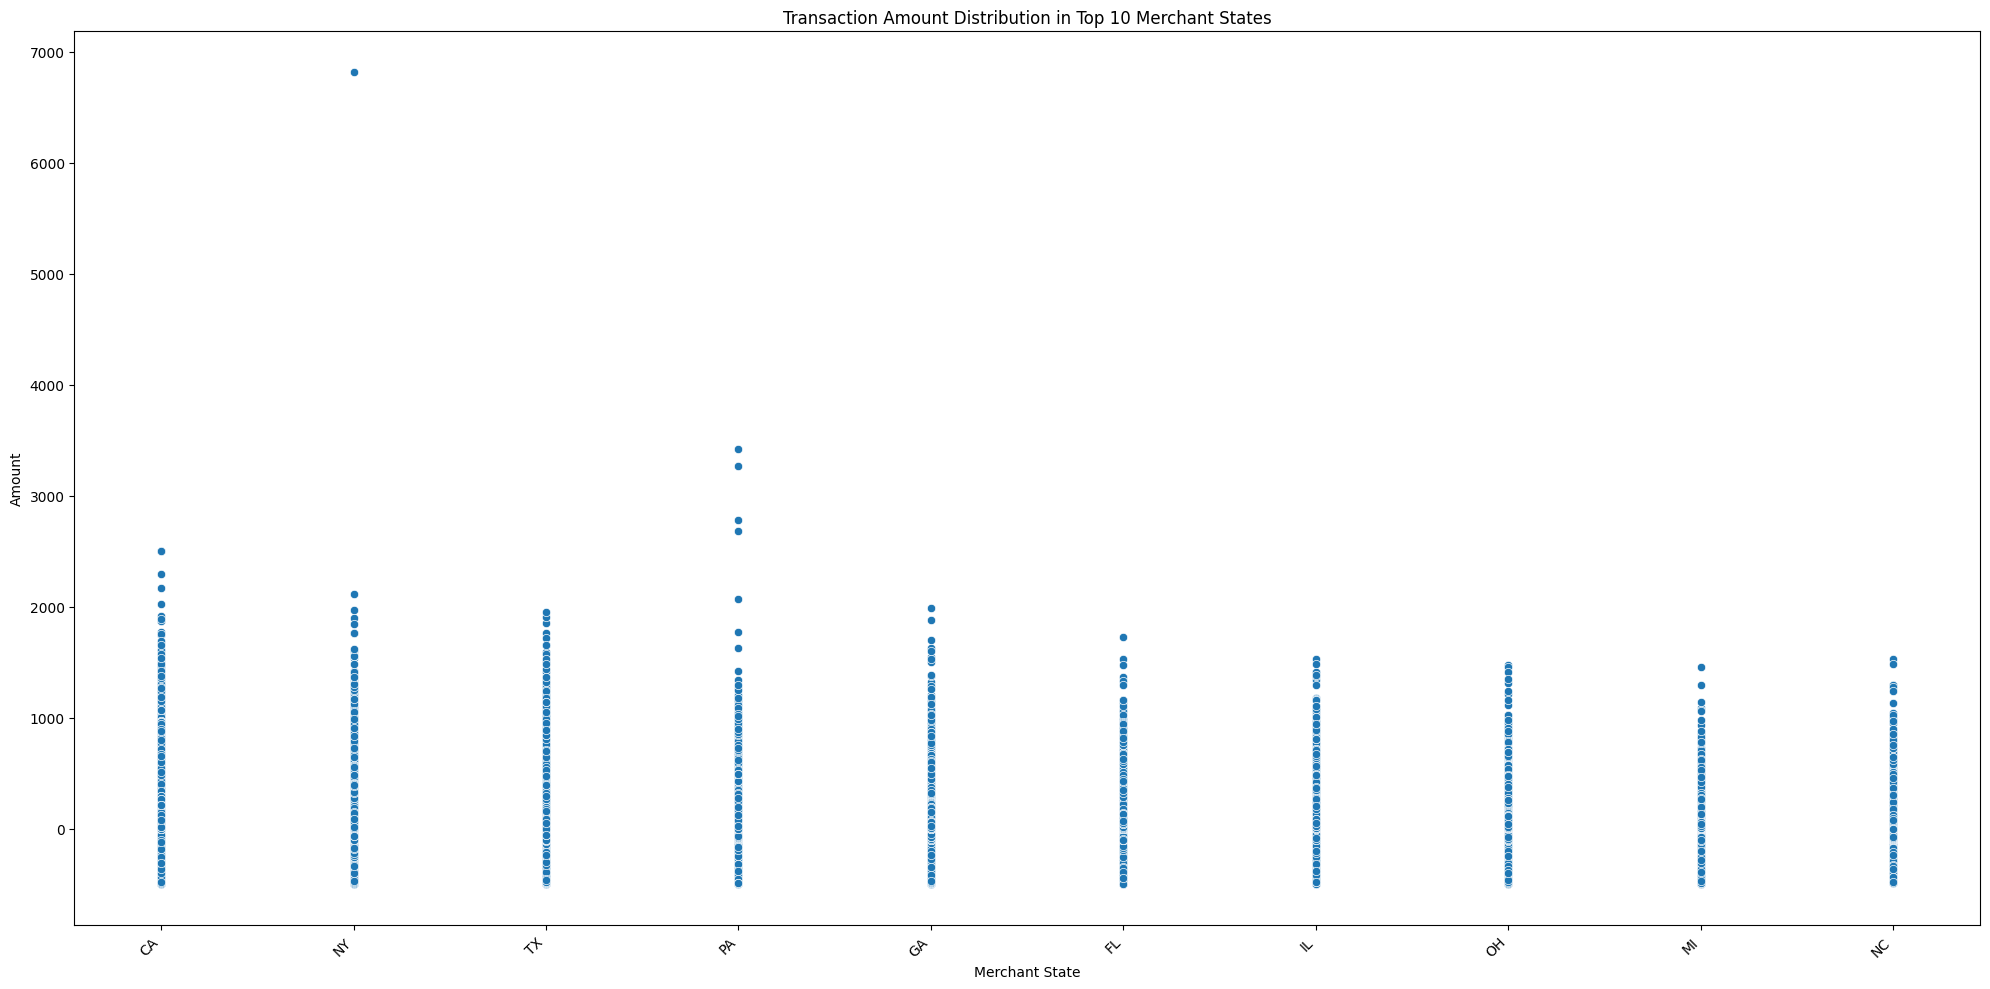

In [ ]:
# Get the top states from df_t
top_states = df_t['merchant_state'].value_counts().nlargest(10).index

# Filter the dataframe to include only the top states
df_top_states_amount = df_t[df_t['merchant_state'].isin(top_states)]

sns.scatterplot(data=df_top_states_amount, x='merchant_state', y='amount')
plt.gcf().set_size_inches(20, 10) # Increase figure size
plt.title("Transaction Amount Distribution in Top 10 Merchant States")
plt.xlabel("Merchant State")
plt.ylabel("Amount")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2428990062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_mcc_description_percentage.index, y=top_10_mcc_description_percentage.values, palette="viridis")


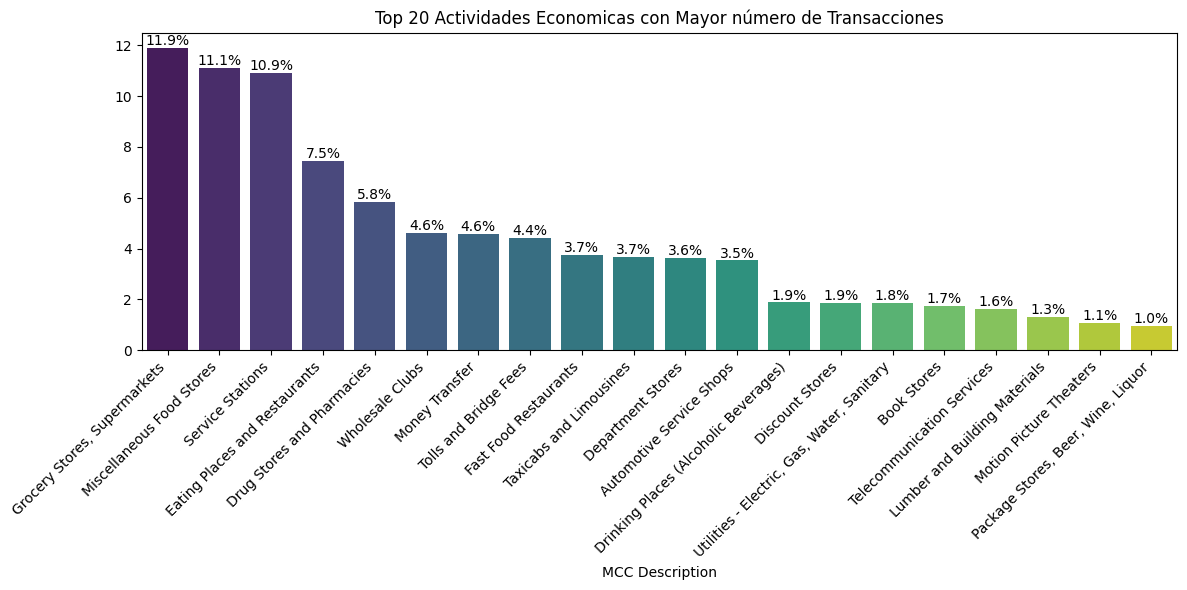

In [ ]:
df_t_merged = pd.merge(df_t, df3, left_on='mcc', right_on='MCC_Code', how='left')
mcc_description_counts = df_t_merged['Description'].value_counts().nlargest(20)
top_10_mcc_description_percentage = (mcc_description_counts / len(df_t_merged)) * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_10_mcc_description_percentage.index, y=top_10_mcc_description_percentage.values, palette="viridis")
plt.xlabel("MCC Description")
plt.title("Top 20 Actividades Economicas con Mayor número de Transacciones")
plt.xticks(rotation=45, ha='right')

# Add percentages on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

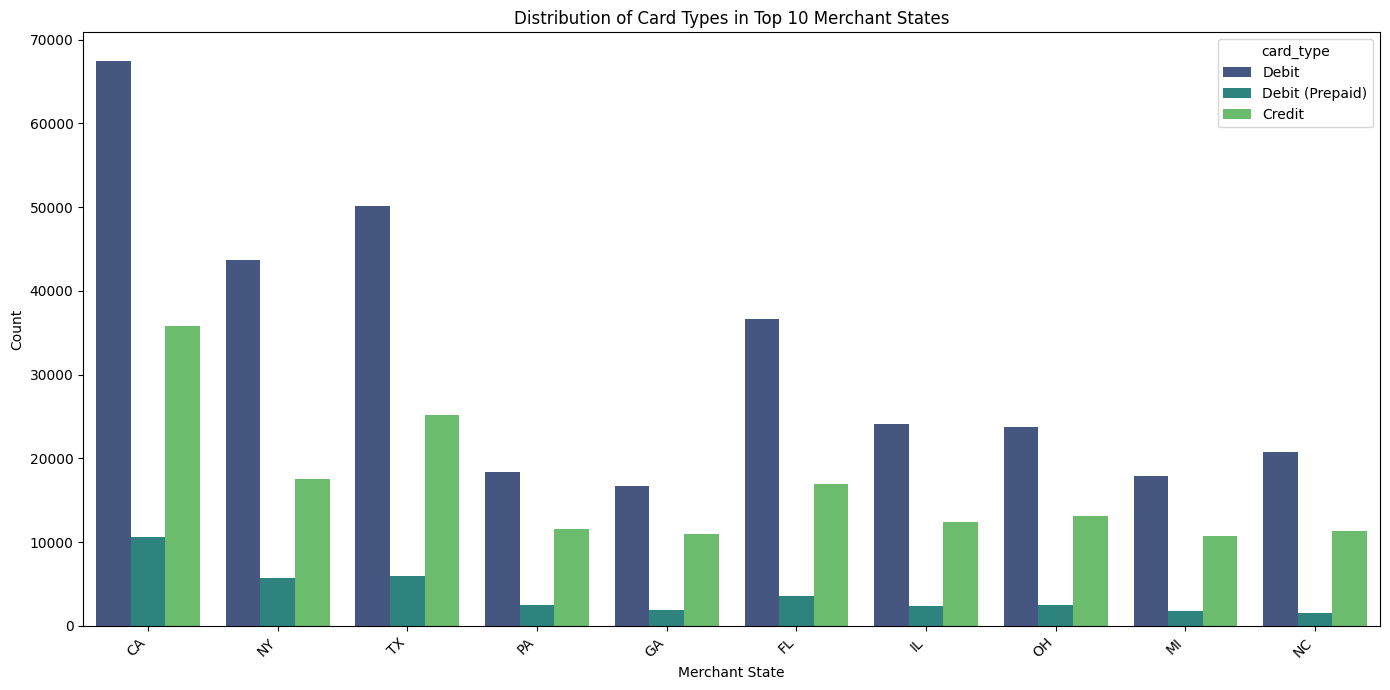

In [ ]:
# Get the top states from df_t
top_states = df_t['merchant_state'].value_counts().nlargest(10).index

# Filter the merged dataframe to include only the top states
df_top_states = df_merged_tc[df_merged_tc['merchant_state'].isin(top_states)]

plt.figure(figsize=(14, 7))
sns.countplot(data=df_top_states, x='merchant_state', hue='card_type', palette='viridis')
plt.xlabel("Merchant State")
plt.ylabel("Count")
plt.title("Distribution of Card Types in Top 10 Merchant States")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

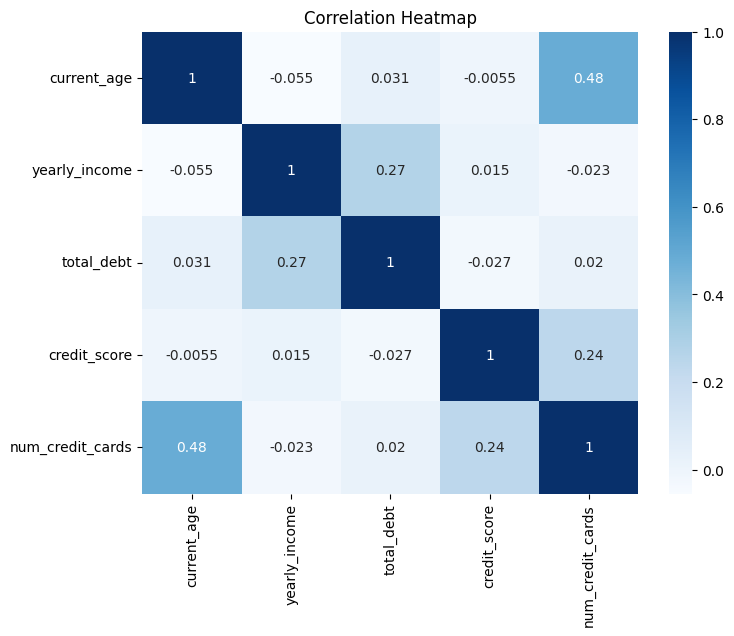

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_u[["current_age","yearly_income","total_debt","credit_score","num_credit_cards"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

Unique values before cleaning: [24295 21968 46414 ... 17116  2468 28074]
Unique values after cleaning: [24295 21968 46414 ... 17116  2468 28074]


/tmp/ipython-input-2080248490.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="card_type", y="credit_limit", data=df_c, palette="PuBu_d", hue=None)


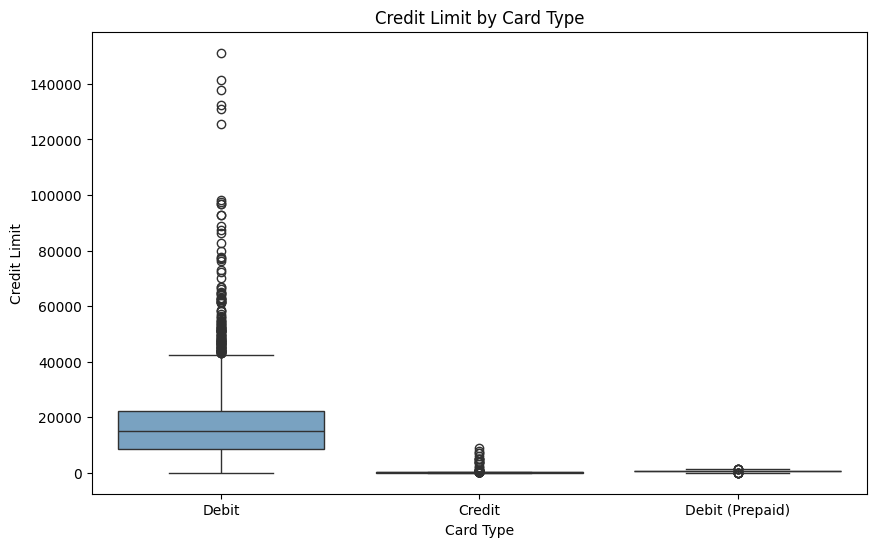

In [ ]:
import re
import numpy as np

def clean_currency(s):
    if isinstance(s, str):
        # Remove dollar signs, commas, and spaces
        s = s.replace('$', '').replace(',', '').strip()
        try:
            return float(s)
        except ValueError:
            # If conversion fails, return NaN
            return np.nan
    # If the input is not a string (e.g., already a number or NaN), return as is
    return s

# Print unique values before cleaning to diagnose
print("Unique values before cleaning:", df_c['credit_limit'].unique())

df_c['credit_limit'] = df_c['credit_limit'].apply(clean_currency)

# Check for any remaining non-numeric values (should be NaN if any)
print("Unique values after cleaning:", df_c['credit_limit'].unique())


plt.figure(figsize=(10,6)) # Increased figure size
sns.boxplot(x="card_type", y="credit_limit", data=df_c, palette="PuBu_d", hue=None)
plt.xlabel("Card Type")
plt.ylabel("Credit Limit")
plt.title("Credit Limit by Card Type")
plt.show()

/tmp/ipython-input-2315967815.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Description', y='amount', data=df_top_mcc, palette='viridis')


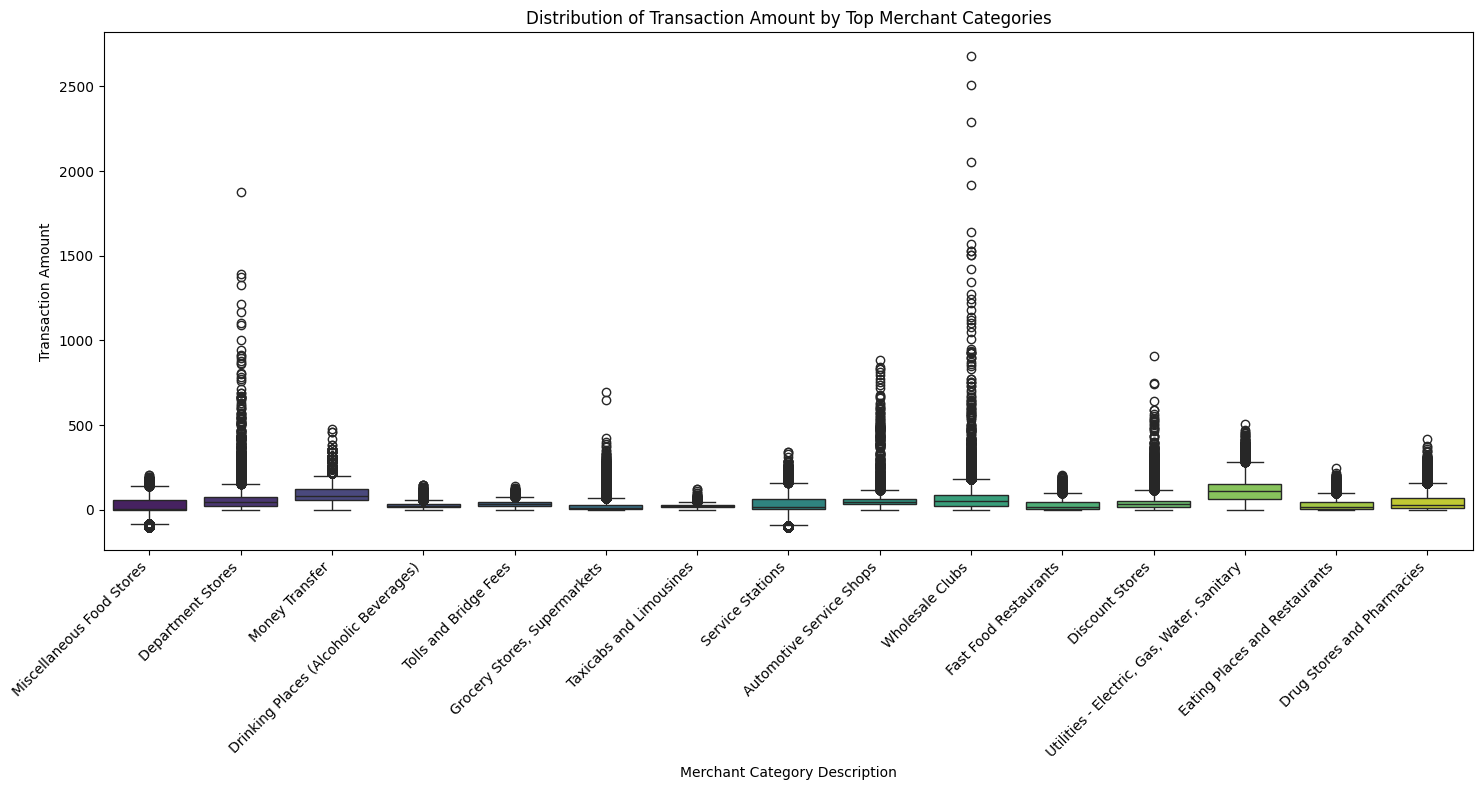

In [ ]:
# Get the top merchant descriptions based on transaction count
top_mcc_descriptions = df_t_merged['Description'].value_counts().nlargest(15).index

# Filter the merged dataframe to include only the top merchant descriptions
df_top_mcc = df_t_merged[df_t_merged['Description'].isin(top_mcc_descriptions)]

plt.figure(figsize=(15, 8))
sns.boxplot(x='Description', y='amount', data=df_top_mcc, palette='viridis')
plt.xlabel("Merchant Category Description")
plt.ylabel("Transaction Amount")
plt.title("Distribution of Transaction Amount by Top Merchant Categories")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

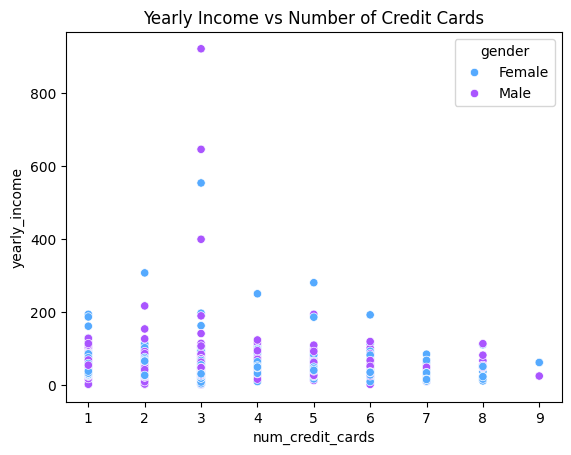

In [ ]:
sns.scatterplot(x='num_credit_cards', y='yearly_income', hue='gender', data=df_u, palette='cool')
plt.title('Yearly Income vs Number of Credit Cards')
plt.show()

/tmp/ipython-input-4153590837.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_merged_uc, x='current_age', y='credit_limit', alpha=0.5,palette='cool')


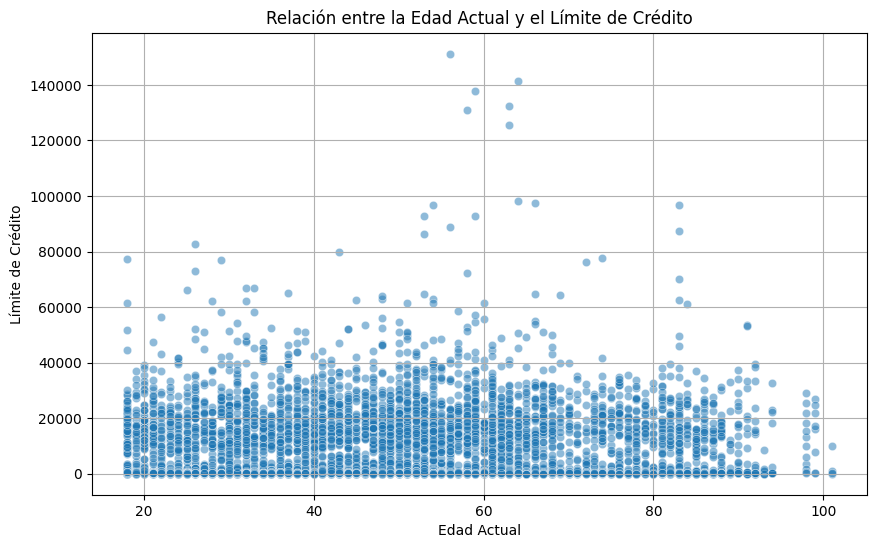

In [ ]:
# Merge df_u and df_c on client_id
df_merged_uc = pd.merge(df_u, df_c, left_on='id', right_on='client_id', how='left')

# Create a scatter plot of current_age vs credit_limit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged_uc, x='current_age', y='credit_limit', alpha=0.5,palette='cool')
plt.title('Relación entre la Edad Actual y el Límite de Crédito')
plt.xlabel('Edad Actual')
plt.ylabel('Límite de Crédito')
plt.grid(True)
plt.show()

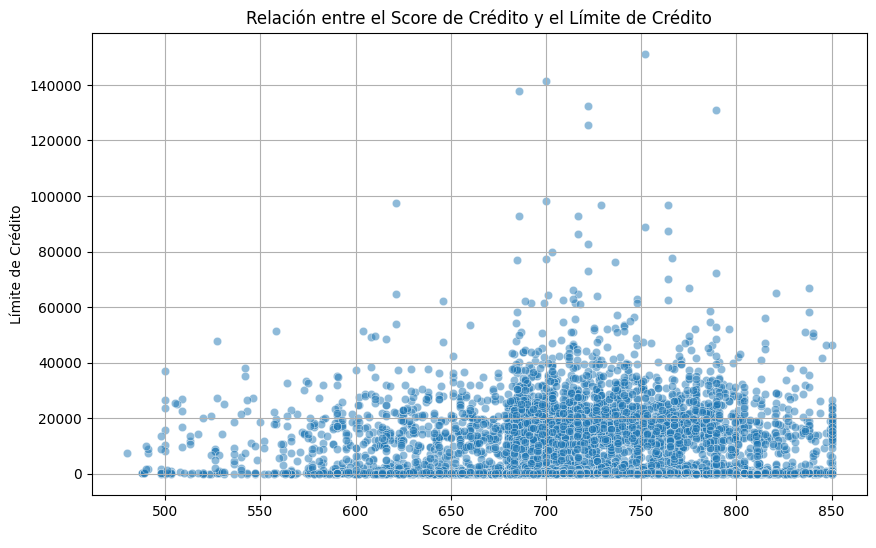

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged_uc, x='credit_score', y='credit_limit', alpha=0.5)
plt.title('Relación entre el Score de Crédito y el Límite de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Límite de Crédito')
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px
import plotly.offline as py
py.init_notebook_mode(connected=True)

fig = px.scatter_geo(df_u, lat='latitude' , lon='longitude', color="yearly_income", size="total_debt", title="Geographical Distribution of Users")
fig.update_layout(height=600)
fig.show()

# 6. Visualizaciones Sweetviz

In [ ]:
# analyzing the dataset TRANSACCIONES
report = sv.analyze([df_t, 'Transactions_data'])

In [ ]:
# show the report in a form of an HTML file
report.show_html('Report.html')

In [ ]:
from google.colab import files
files.download("Report.html")


In [ ]:
# analyzing the dataset #CARDS
report = sv.analyze([df_c, 'cards_data'])

In [ ]:
# show the report in a form of an HTML file
report.show_html('Report.html')

In [ ]:
from google.colab import files
files.download("Report.html")

In [ ]:
# analyzing the dataset USERS
report = sv.analyze([df_t, 'users_data'])

In [ ]:
# show the report in a form of an HTML file
report.show_html('Report.html')

In [ ]:
from google.colab import files
files.download("Report.html")